# Aula 10 — pandas: filtros, agrupamento (`groupby`) e junções (`merge`)

**Semana 5** | 50 min | Referências: VanderPlas, *Python Data Science Handbook*, Cap. 3 · McKinney, *Python for Data Analysis*, Caps. 7 e 9

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Filtrar linhas com **máscaras vetoriais** (`df[df["col"] > valor]`) e combinar critérios com `&` / `|`;
- Criar **colunas derivadas** (gasto total, razão alimentação/renda) sem escrever um laço;
- Usar `groupby` (split-apply-combine) com `.agg()` e **named aggregation** para resumos estatísticos;
- Construir tabelas de contingência com `pivot_table` (UF × situação, renda média);
- Combinar bases com `pd.merge` (`inner`/`left`/`outer`) e diagnosticar quantas linhas sobrevivem a cada junção.

## 1. Da série ao sistema de tabelas

**Intuição econômica.** A Aula 09 trabalhou com uma tabela só. A pesquisa real —
PNAD, POF 2017-18 do IBGE, balanços de clientes — chega **desmembrada**: um arquivo
de moradores, outro de domicílios, outro de despesas. A análise de pobreza e
consumo (raiz da teoria de Engel) exige três operações: **filtrar** (quem rende
mais), **resumir** (média por grupo) e **juntar** (renda + despesa por família).
São exatamente `df[...]`, `groupby` e `merge`.

A base é a **POF 2017-18** (Pesquisa de Orçamentos Familiares, IBGE): 57.920
domicílios, com a renda per capita do responsável e as despesas anualizadas por
categoria. Usaremos estatísticas **não-ponderadas** (amostra didática).

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

from pathlib import Path
DATA = Path("../data/csv")  # notebook mora em semana_05/

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

In [2]:
# As três tabelas da POF: moradores (pessoas), domicílios, despesas anualizadas
morador = pd.read_csv(DATA / "pof_morador.csv")
domicilio = pd.read_csv(DATA / "pof_domicilio.csv")
despesa = pd.read_csv(DATA / "pof_despesa_categoria.csv")

# ⚠ Morador tem 2.344 registros com a MESMA household_id: são duas pessoas de
# referência no mesmo domicílio (dados de POF). Mantemos a 1ª ocorrência para
# que a base de pessoas tenha 1 linha por domicílio (1:1 com os outros arquivos):
morador = morador.drop_duplicates(subset="household_id", keep="first")

print(morador.shape, domicilio.shape, despesa.shape)
morador.head(3)

(57920, 5) (57920, 3) (57799, 6)


,household_id,ANOS_EST,NIVEL_INST,RENDA_PC,hh_size
0,110000016_2,5,2,1237.183056,3
1,110000016_3,12,5,1265.644167,4
2,110000016_4,5,2,1317.676667,2


## 2. Filtros vetoriais: o `df[...]` que substitui 57 mil linhas de `if`

In [3]:
# Máscara booleana: comparação vetorizada → True/False por linha → filtro
pobres = morador[morador["RENDA_PC"] < 0.5 * 1518]   # ≤ R$ 759 (meio salário mínimo 2026)
print(f"Famílias com renda pc < meio salário mínimo: {len(pobres)} de {len(morador)}")
print("Renda média desse grupo:", brl(pobres["RENDA_PC"].mean()))

Famílias com renda pc < meio salário mínimo: 17381 de 57920
Renda média desse grupo: R$ 471,75


In [4]:
# Combinação de critérios: & (e) / | (ou) com PARÊNTESES obrigatórios (precedência do Python)
alfab_ensino_medio = morador[
    (morador["ANOS_EST"] >= 12) & (morador["NIVEL_INST"] >= 5)
]
print(f"Analfabetismo funcional (≥12 anos de estudo, nível ≥ 5): {len(alfab_ensino_medio)} famílias")
print("Renda média:", brl(alfab_ensino_medio["RENDA_PC"].mean()))
print("\n| ou |: com superior completo OU 15+ anos de estudo:")
so_um = morador[(morador["NIVEL_INST"] == 7) | (morador["ANOS_EST"] >= 15)]
print(len(so_um), "famílias | renda média:", brl(so_um["RENDA_PC"].mean()))

Analfabetismo funcional (≥12 anos de estudo, nível ≥ 5): 21732 famílias
Renda média: R$ 2.456,16

| ou |: com superior completo OU 15+ anos de estudo:
7380 famílias | renda média: R$ 3.908,82


In [5]:
# Atalhos declarativos: .isin() (lista de valores) e .between() (faixa de renda)
so_rj_go = domicilio[domicilio["UF"].isin([33, 52])]
print(f"UF 33 (RJ) + UF 52 (GO): {len(so_rj_go)} domicílios")

classe_c = morador[morador["RENDA_PC"].between(1000, 3000)]
print(f"Renda pc entre R$ 1.000 e R$ 3.000: {len(classe_c)} famílias ({len(classe_c)/len(morador):.1%})")

UF 33 (RJ) + UF 52 (GO): 5412 domicílios
Renda pc entre R$ 1.000 e R$ 3.000: 26751 famílias (46.2%)


**Erro clássico** — `morador["ANOS_EST"] >= 12 and morador["NIVEL_INST"] >= 5` com
`and`/`or` textuais levanta `ValueError` (a verdade de um array é ambígua); use `&`
e `|` **com parênteses** em cada comparação.

## 3. Colunas derivadas: a razão alimentação/renda em uma linha

In [6]:
# Base única: juntar as três tabelas (inner: só famílias com as 3 informações)
pof = domicilio.merge(morador, on="household_id", how="inner")
pof = pof.merge(despesa, on="household_id", how="inner")

CATS = ["food", "housing", "transport", "health", "other"]
pof["desp_total"] = pof[CATS].sum(axis=1)          # gasto anualizado total
pof["w_food"] = pof["food"] / pof["desp_total"]     # razão alimentação / total (Engel)
pof["prop_renda"] = pof["desp_total"] / (12 * pof["RENDA_PC"])  # despesa anual ÷ renda anual pc
print(pof.shape)
pof[["RENDA_PC", "desp_total", "w_food", "prop_renda"]].describe().round(2)

(57799, 15)


,RENDA_PC,desp_total,w_food,prop_renda
count,57799.00,57799.00,57799.00,57799.00
mean,1689.54,6561.11,0.65,0.47
std,2472.20,16121.70,0.26,9.13
min,-1658.74,10.50,0.00,-1915.14
25%,672.38,2380.44,0.45,0.17
50%,1156.66,4210.91,0.68,0.31
75%,1897.89,7176.50,0.88,0.54
max,237868.97,1314046.60,1.00,890.97


**Leitura do resultado.** `desp_total` é despesa **anualizada e deflacionada**; a
razão `w_food` é o coeficiente de **Engel** — a fração do gasto em alimentação,
que cai conforme a renda sobe (Lei de Engel). Note que a média de `prop_renda` pode
ultrapassar 1: a despesa agregada do domicílio não é só do responsável cuja renda
observamos (renda pc do responsável ≠ renda total da família) — bom motivo para
analisar por **faixa** de renda, não por domicílio isolado.

## 4. `groupby`: dividir, aplicar, combinar

In [7]:
# groupby em 1 passo: agrupa por NIVEL_INST e tira a média da renda por grupo
por_nivel = pof.groupby("NIVEL_INST")["RENDA_PC"].mean()
print(por_nivel.round(0))

NIVEL_INST
1    1075.0
2    1219.0
3    1425.0
4    1253.0
5    1660.0
6    2325.0
7    4032.0
Name: RENDA_PC, dtype: float64


In [8]:
# .agg() com múltiplas funções: média, mediana, desvio e contagem numa chamada só
resumo = pof.groupby("NIVEL_INST")["RENDA_PC"].agg(
    media="mean", mediana="median", desvio="std", n="size"
)
resumo.round(0)

,media,mediana,desvio,n
NIVEL_INST,,,,
1,1075.0,923.0,1155.0,5315
2,1219.0,988.0,1146.0,23061
3,1425.0,1073.0,1685.0,4805
4,1253.0,942.0,1272.0,2911
5,1660.0,1231.0,1952.0,13126
6,2325.0,1699.0,2397.0,1790
7,4032.0,2709.0,5307.0,6791


In [9]:
# Named aggregation: N colunas × M funções com nomes que VOCÊ escolhe — pronto p/ tabela
uf_resumo = (
    pof
    .groupby("UF")
    .agg(
        renda_media=("RENDA_PC", "mean"),
        renda_p90=("RENDA_PC", lambda s: s.quantile(0.9)),
        gasto_medio=("desp_total", "mean"),
        n_domicilios=("household_id", "size"),
    )
    .round(0)
)
uf_resumo.loc[[11, 26, 31, 33, 52, 53]]   # RO, SP, MG, RJ, GO, DF: leitura regional

,renda_media,renda_p90,gasto_medio,n_domicilios
UF,,,,
11,1398.0,2528.0,5726.0,947
26,1293.0,2481.0,4838.0,3104
31,1820.0,3286.0,6448.0,4527
33,2085.0,4191.0,6936.0,3173
52,1703.0,3020.0,6697.0,2226
53,3303.0,7680.0,11660.0,1330


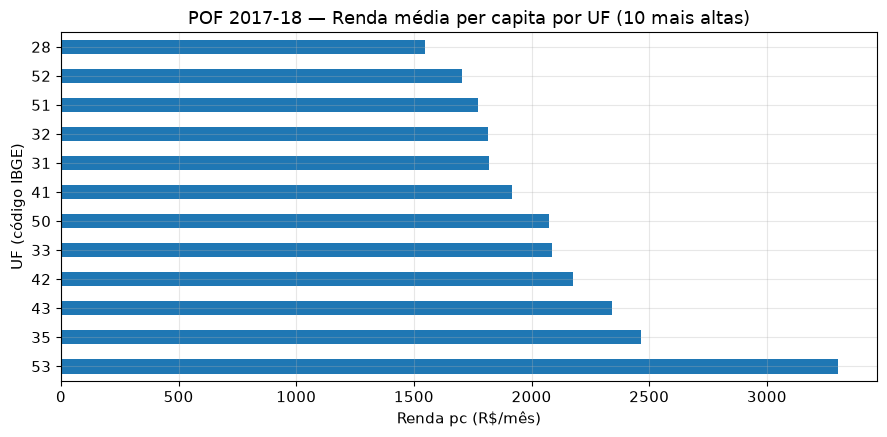

In [10]:
# Visualizar: barra horizontal da renda média por UF — GO (52) no contexto nacional
uf_top = uf_resumo.sort_values("renda_media", ascending=False).head(12)
ax = uf_top["renda_media"].plot.barh(
    title="POF 2017-18 — Renda média per capita por UF (10 mais altas)",
    xlabel="Renda pc (R$/mês)", ylabel="UF (código IBGE)",
)
plt.tight_layout()
plt.show()

## 5. `pivot_table`: a tabela cruzada do economista

In [11]:
# pivot_table: linhas = UF, colunas = situação (1 urbano / 2 rural), valores = renda média
tabela = pof.pivot_table(
    index="UF", columns="SITUACAO", values="RENDA_PC", aggfunc="mean"
).round(0)
tabela.columns = ["urbano", "rural"]      # renomear para leitura
print("Renda média pc — urbano vs rural (seleção de UFs):")
print(tabela.loc[[11, 26, 31, 33, 52, 53]])

# gap urbano-rural em Goiás (UF 52):
print("\nGAP urbano-rural em Goiás:", brl(tabela.loc[52, "urbano"] - tabela.loc[52, "rural"]))

Renda média pc — urbano vs rural (seleção de UFs):
    urbano   rural
UF                
11  1484.0  1207.0
26  1381.0   762.0
31  2009.0  1284.0
33  2181.0  1206.0
52  1755.0  1639.0
53  3479.0  1777.0

GAP urbano-rural em Goiás: R$ 116,00


In [12]:
# margins=True adiciona as linhas/colunas 'All' — o total geral da tabela cruzada
tabela_m = pof.pivot_table(
    index="UF", columns="SITUACAO", values="RENDA_PC", aggfunc="mean", margins=True
).round(0)
tabela_m.columns = ["urbano", "rural", "total"]
tabela_m.loc[[11, 26, 31, 33, 52, 53]]

,urbano,rural,total
UF,,,
11,1484.0,1207.0,1398.0
26,1381.0,762.0,1293.0
31,2009.0,1284.0,1820.0
33,2181.0,1206.0,2085.0
52,1755.0,1639.0,1703.0
53,3479.0,1777.0,3303.0


## 6. `merge`: juntar tabelas como no SQL

In [13]:
# Tipos de merge — mesma operação, comportamentos distintos sobre household_id:
n_inner = len(domicilio.merge(morador, on="household_id", how="inner"))
n_left  = len(domicilio.merge(morador, on="household_id", how="left"))
n_outer = len(domicilio.merge(morador, on="household_id", how="outer"))
print(f"domicílios: {len(domicilio)} | moradores: {len(morador)}")
print(f"inner: {n_inner} | left: {n_left} | outer: {n_outer}")
print(f"domicílios sem morador (outer − inner): {n_outer - n_inner}")

domicílios: 57920 | moradores: 57920


inner: 57920 | left: 57920 | outer: 57920
domicílios sem morador (outer − inner): 0


In [14]:
# inner: só as famílias com as TRÊS bases — a base limpa para a análise de Engel
pof_inner = domicilio.merge(morador, on="household_id", how="inner").merge(
    despesa, on="household_id", how="inner"
)

# Repetimos as colunas derivadas na base inner (a seção 3 as criou na base left):
CATS = ["food", "housing", "transport", "health", "other"]
pof_inner["desp_total"] = pof_inner[CATS].sum(axis=1)
pof_inner["w_food"] = pof_inner["food"] / pof_inner["desp_total"]

print(f"inner: {len(pof_inner)} famílias (todas as 3 bases)")
print(f"UF=52 (Goiás) nesse recorte: {(pof_inner['UF'] == 52).sum()} famílias goianas")

inner: 57799 famílias (todas as 3 bases)
UF=52 (Goiás) nesse recorte: 2226 famílias goianas


## 7. O caso real: renda × estrutura de gasto em Goiás (UF = 52)

In [15]:
# O caso: separar Goiás, criar faixas de renda (quartis) e medir Engel por faixa
go = pof_inner[pof_inner["UF"] == 52].copy()
go["faixa"] = pd.qcut(go["RENDA_PC"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
print(f"Famílias goianas com base completa: {len(go)}")
go[["RENDA_PC", "desp_total", "w_food"]].describe().round(2)

Famílias goianas com base completa: 2226


,RENDA_PC,desp_total,w_food
count,2226.00,2226.00,2226.00
mean,1702.75,6697.07,0.62
std,1610.84,18195.34,0.27
min,-69.72,20.55,0.00
25%,862.88,2505.59,0.42
50%,1315.19,4407.72,0.65
75%,1952.46,7074.06,0.87
max,23157.14,527331.06,1.00


       renda_media  w_food    n
faixa                          
Q1         608.398   0.654  557
Q2        1087.187   0.624  556
Q3        1589.082   0.632  556
Q4        3525.014   0.590  557


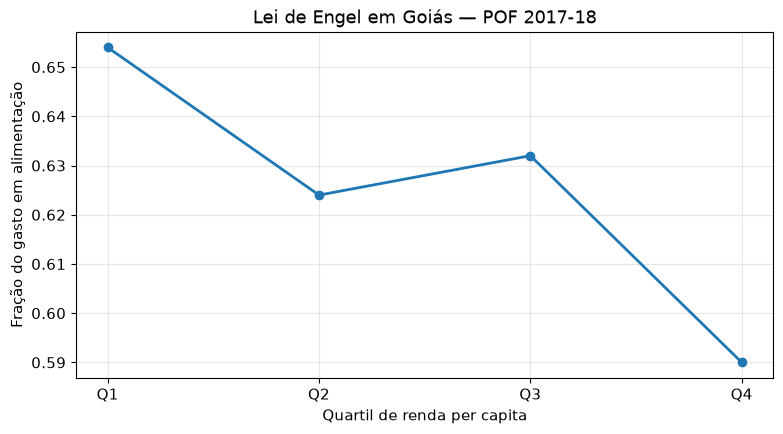

In [16]:
# Lei de Engel em Goiás: a fração do gasto em alimentação CAI conforme a renda sobe
engel = go.groupby("faixa").agg(
    renda_media=("RENDA_PC", "mean"),
    w_food=("w_food", "mean"),
    n=("w_food", "size"),
).round(3)
print(engel)

fig, ax = plt.subplots()
ax.plot(engel.index.astype(str), engel["w_food"], marker="o", linewidth=2)
ax.set(title="Lei de Engel em Goiás — POF 2017-18",
       xlabel="Quartil de renda per capita", ylabel="Fração do gasto em alimentação")
plt.show()

        food  housing  transport  health  other
faixa                                          
Q1     0.553    0.150      0.014   0.054  0.230
Q2     0.535    0.066      0.011   0.142  0.246
Q3     0.453    0.087      0.151   0.099  0.210
Q4     0.401    0.100      0.117   0.147  0.235


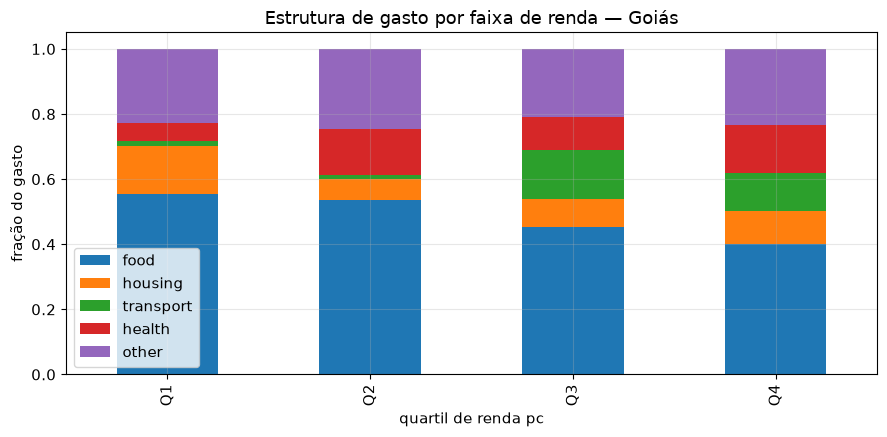

In [17]:
# Estrutura de gasto por quartil: onde cada faixa coloca o dinheiro (média da fração)
estrutura = go.groupby("faixa")[CATS].mean()
estrutura_pct = estrutura.div(estrutura.sum(axis=1), axis=0).round(3)
print(estrutura_pct)
estrutura_pct.plot.bar(stacked=True, title="Estrutura de gasto por faixa de renda — Goiás",
                       ylabel="fração do gasto", xlabel="quartil de renda pc")
plt.tight_layout(); plt.show()

## 📝 Exercícios

### Exercício 1 — Quem estuda mais estuda em Goiás?

Com a base `pof` (domicílio + morador + despesa, inner) filtre **apenas Goiás**
(`UF == 52`) e responda com `groupby` + `agg`: (a) quantas famílias por
`NIVEL_INST`; (b) a renda média por nível de instrução; (c) em uma frase: o gradiente
de renda por educação em Goiás é mais forte ou mais fraco que o nacional (compare
com `uf_resumo` ou a seção 4)?

In [18]:
# EXERCÍCIO 1 — seu código aqui



In [19]:
# SOLUÇÃO 1 — renda por escolaridade, Goiás vs Brasil
grad_go = (
    go.groupby("NIVEL_INST")["RENDA_PC"]
    .agg(n="size", renda_media="mean")
    .round(0)
)
print(grad_go)
grad_br = pof_inner.groupby("NIVEL_INST")["RENDA_PC"].mean().round(0)

comp = pd.DataFrame({"goias": grad_go["renda_media"], "brasil": grad_br})
comp["razao_go_br"] = (comp["goias"] / comp["brasil"]).round(2)
print(comp)
# Frase: o gradiente em Goiás é parecido com o nacional (razões próximas de 1) —
# a escolaridade paga aproximadamente a mesma premia relativa, em nível de renda menor.

               n  renda_media
NIVEL_INST                   
1            189       1378.0
2           1064       1471.0
3            171       1442.0
4            117       1522.0
5            445       1801.0
6             56       2084.0
7            184       3381.0
             goias  brasil  razao_go_br
NIVEL_INST                             
1           1378.0  1075.0         1.28
2           1471.0  1219.0         1.21
3           1442.0  1425.0         1.01
4           1522.0  1253.0         1.21
5           1801.0  1660.0         1.08
6           2084.0  2325.0         0.90
7           3381.0  4032.0         0.84


### Exercício 2 — Engel por faixa: sua própria tabela

Refaça a análise da seção 7 com **quintis** (5 faixas, `pd.qcut(..., 5)`) em vez de
quartis, em Goiás, e responda: a fração em alimentação do Q1 (mais pobre) é quanto
da fração do Q5? Comente a Lei de Engel em uma frase.

In [20]:
# EXERCÍCIO 2 — seu código aqui



In [21]:
# SOLUÇÃO 2 — quintis e a razão Q1/Q5
go_q5 = go.copy()
go_q5["faixa5"] = pd.qcut(go_q5["RENDA_PC"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
engel5 = go_q5.groupby("faixa5", observed=True)["w_food"].mean().round(3)
print(engel5)
razao = engel5["Q1"] / engel5["Q5"]
print(f"\nQ1 gasta em alimentação {razao:.2f}× a fração do Q5")
# Frase: quanto mais pobre a família, maior a fatia do orçamento que vai para comida —
# a Lei de Engel, agora com 5 faixas em vez de 4.

faixa5
Q1    0.662
Q2    0.616
Q3    0.650
Q4    0.613
Q5    0.585
Name: w_food, dtype: float64

Q1 gasta em alimentação 1.13× a fração do Q5


### Exercício 3 — pivot_table por situação e UF

Construa uma `pivot_table` com **linhas = UF** e **colunas = SITUACAO**, valores =
**despesa média total** (`desp_total`, `aggfunc='mean'`). Compare **apenas Goiás**
(UF 52) e o **DF** (UF 53): quanto gasta mais, em média, um domicílio urbano do DF
vs um rural goiano?

In [22]:
# EXERCÍCIO 3 — seu código aqui



In [23]:
# SOLUÇÃO 3 — despesa média, urbano vs rural, GO vs DF
tab = pof_inner.pivot_table(
    index="UF", columns="SITUACAO", values="desp_total", aggfunc="mean"
)
tab.columns = ["urbano", "rural"]
print(tab.loc[[52, 53]].round(0))
gap = tab.loc[53, "urbano"] - tab.loc[52, "rural"]
print(f"\nUrbano DF vs Rural GO: {brl(gap)} de diferença na despesa anualizada")

     urbano   rural
UF                 
52   7354.0  5894.0
53  12259.0  6479.0

Urbano DF vs Rural GO: R$ 6.365,22 de diferença na despesa anualizada


### Exercício 4 — merge left: o que sobra e o que falta?

A pesquisa de campo entregou `despesa` incompleta (alguns domicílios não
responderam). Faça o **left merge** `domicilio.merge(despesa, on="household_id",
how="left")` e responda: (a) quantas linhas tem o resultado; (b) quantas têm
despesa faltando (`food` NaN) — as famílias que a pesquisa perdeu; (c) em uma
frase: por que o **inner** devolveria menos?

In [24]:
# EXERCÍCIO 4 — seu código aqui



In [25]:
# SOLUÇÃO 4 — diagnosticar perda de linhas no merge
pof_left = domicilio.merge(despesa, on="household_id", how="left")
print(f"(a) linhas com left:  {len(pof_left)}")
print(f"(b) com despesa faltando (food NaN): {pof_left['food'].isna().sum()}")
print(f"(c) inner manteria {len(domicilio.merge(despesa, on='household_id'))} linhas — só os pares completos.")

(a) linhas com left:  57920
(b) com despesa faltando (food NaN): 121


(c) inner manteria 57799 linhas — só os pares completos.


### Exercício 5 — A faixa mais endividada

Crie a coluna `prop_renda` na base `go` (despesa anual ÷ renda anual pc, igual à
seção 3) e use `groupby('faixa')` + named aggregation para responder: qual quartil
de renda tem a **maior** `prop_renda` média? Interprete: é o mais pobre? Isso é
endividamento ou apenas renda do responsável ≠ renda total da família?

In [26]:
# EXERCÍCIO 5 — seu código aqui



In [27]:
# SOLUÇÃO 5 — comprometimento da renda por faixa
go["prop_renda"] = go["desp_total"] / (12 * go["RENDA_PC"])
comp = go.groupby("faixa", observed=True).agg(
    prop_media=("prop_renda", "mean"),
    prop_mediana=("prop_renda", "median"),
    n=("prop_renda", "size"),
).round(2)
print(comp)
print(f"\nMaior comprometimento: faixa {comp['prop_media'].idxmax()}")
# Interpretação: o comprometimento maior em faixas pobres reflete (i) famílias
# com vários membros gerando despesa mas só UMA renda observada (a do responsável)
# e (ii) despesa fixa (aluguel, energia) que não escala com a renda.

       prop_media  prop_mediana    n
faixa                               
Q1           0.74          0.52  557
Q2           0.41          0.33  556
Q3           0.34          0.23  556
Q4           0.27          0.16  557

Maior comprometimento: faixa Q1


## 📌 Resumo & para casa

- **Filtros vetoriais**: `df[df['col'] > v]`, combinados com `&`/`|` (parênteses obrigatórios) ou `.isin()`/`.between()` — 57.920 linhas sem um laço.
- **Colunas derivadas**: `df['nova'] = ...` cria a coluna inteira em uma linha — gasto total, coeficiente de Engel, comprometimento de renda.
- **`groupby`** = split-apply-combine; `.agg()` empilha funções; **named aggregation** dá nomes legíveis às colunas de saída.
- **`pivot_table`**: linhas × colunas × valor — a tabela cruzada do relatório (UF × situação × renda média).
- **`merge`**: `inner` (pares completos), `left` (mantém a esquerda, NaN onde falta), `outer` (tudo) — conte as linhas antes e depois para saber o que sobreviveu.
- **Lei de Engel** na POF 2017-18: a fração do gasto em alimentação cai de ≈ 65% (Q1) para ≈ 59% (Q4) em Goiás.

**Para casa:** reexecute a análise da seção 7 trocando UF 52 (Goiás) por UF 53 (DF) e compare os coeficientes de Engel quartil a quartil.

**Próxima aula:** Aula 11 — `matplotlib` fundamentos: os gráficos destas duas aulas viram figuras de relatório (eixo, título, legenda, múltiplos painéis).

**Referências (KB):**
- `kb/02_vanderplas_python_data_science_handbook/06_chapter-3-data-manipulation-with-pandas.md` — seções *Hierarchical Indexing*, *Combining Datasets: Concat and Append*, *Aggregation and Grouping*.
- `kb/01_mckinney_python_for_data_analysis/09_chapter-7-data-wrangling-clean-transform-merge-reshape.md` — merge, pivoteamento, filtros.
- `kb/01_mckinney_python_for_data_analysis/11_chapter-9-data-aggregation-and-group-operations.md` — groupby em profundidade, apply.